In [1]:
import sys
print(sys.executable)

from sentence_transformers import SentenceTransformer, util
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load a pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The dog barked loudly.",
    "A loud noise came from the dog.",
    "She baked a cake.",
    "He cooked dinner.",
    "The sky is blue.",
    "The clouds are dark."
]

# embedding via the sentence transformer model
embeddings = model.encode(sentences)

# Using cosine similarity to find difference in angles between the embeddings
cosine_scores = util.cos_sim(embeddings, embeddings)

# Convert to a readable DataFrame
matrix_df = pd.DataFrame(cosine_scores.numpy(), index=sentences, columns=sentences)
print(matrix_df)

c:\Users\Devan\Desktop\AI-Algorithm-Design-and-Analysis---705.623\Discussion Activities\Module 11\venv\Scripts\python.exe


c:\Users\Devan\Desktop\AI-Algorithm-Design-and-Analysis---705.623\Discussion Activities\Module 11\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6139.61it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                 The dog barked loudly.  \
The dog barked loudly.                         1.000000   
A loud noise came from the dog.                0.718083   
She baked a cake.                              0.070343   
He cooked dinner.                              0.117898   
The sky is blue.                              -0.049503   
The clouds are dark.                           0.039309   

                                 A loud noise came from the dog.  \
The dog barked loudly.                                  0.718083   
A loud noise came from the dog.                         1.000000   
She baked a cake.                                       0.142738   
He cooked dinner.                                       0.186482   
The sky is blue.                                        0.043033   
The clouds are dark.                                    0.094006   

                                 She baked a cake.  He cooked dinner.  \
The dog barked loudly.              

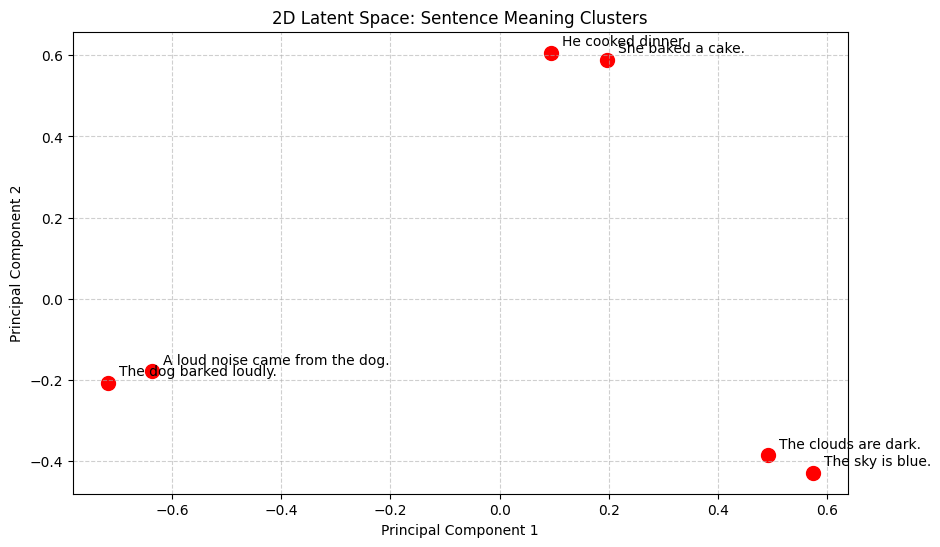

In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Reduce from 384 dimensions down to 2 dimensions using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='red', s=100)

# 3. Add the sentences as labels next to each dot
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 xytext=(8, 5), 
                 textcoords='offset points',
                 fontsize=10)

plt.title("2D Latent Space: Sentence Meaning Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()